# Shortpick v3 R14 Rank5 replacement-quality analysis

## tl;dr

The exact R14 baseline replay passed, but none of the six preregistered, signal-day-only Rank5 quality filters cleared the one-in-one-out gate. The best near miss added only 0.282 percentage points of total return while increasing order skips. Retain R14 and stop tuning simple Rank5 thresholds on this sample.

## Context & Methods

The decision is whether one Rank5 replacement-quality rule should replace R14 without adding a fourth active strategy role. Six thresholds were frozen before candidate outcome evaluation and replayed on the deterministic R14 execution snapshot. Promotion requires exact replay, non-degradation on nine metrics versus both the reproducible baseline and the legacy R14 display contract, plus a material breakthrough or one fewer losing month.

### Key Assumptions

- Candidate selection may use only same-signal-day score, liquidity, momentum percentiles, and distance from the 20-day high.
- Inventory outcome columns are present for historical diagnostics but are forbidden from candidate selection.
- Historical replay is research evidence, not forward performance.

## Data

Load the frozen design and governed experiment, then verify the execution and leakage contracts.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
DESIGN_PATH = ROOT / 'docs/contracts/SHORTPICK_V3_R14_RANK5_REPLACEMENT_QUALITY_DESIGN_2026-07-15.json'
EXPERIMENT_PATH = ROOT / 'docs/contracts/SHORTPICK_V3_R14_RANK5_REPLACEMENT_QUALITY_EXPERIMENT_2026-07-15.json'
design = json.loads(DESIGN_PATH.read_text(encoding='utf-8'))
experiment = json.loads(EXPERIMENT_PATH.read_text(encoding='utf-8'))
assert design['status'] == 'frozen_before_candidate_outcome_evaluation'
assert len(design['candidate_variants']) == 6
assert experiment['source_execution_snapshot']['exact_replay'] is True
assert experiment['feature_contract_validation']['outcome_fields_used_for_candidate_selection'] == []
assert experiment['accepted_candidate_ids'] == []
experiment['decision']

'retain_r14_no_rank5_quality_candidate_cleared_gate'

In [2]:
quality = {
    'selected_pick_count': experiment['source_execution_snapshot']['input_counts']['selected_pick_count'],
    'inventory_row_count': experiment['source_execution_snapshot']['input_counts']['candidate_inventory_row_count'],
    'market_bar_row_count': experiment['source_execution_snapshot']['input_counts']['market_bar_row_count'],
    'ledger_row_count': experiment['source_execution_snapshot']['output_counts']['order_ledger_row_count'],
    'nav_day_count': experiment['source_execution_snapshot']['output_counts']['nav_row_count'],
    'exact_replay': experiment['source_execution_snapshot']['exact_replay'],
}
pd.Series(quality)

selected_pick_count        1533
inventory_row_count       10220
market_bar_row_count    1420262
ledger_row_count           2326
nav_day_count               675
exact_replay               True
dtype: object

## Results

All candidates preserve the same account engine and differ only in the preregistered Rank5 filter.

In [3]:
labels = {
    experiment['variants'][0]['config_id']: 'Reproducible baseline',
    'r14_rank5_score_gap005_research_v1': 'Score gap <= 0.05',
    'r14_rank5_avg_amount_50m_research_v1': '20d amount >= 50m',
    'r14_rank5_return20_p50_research_v1': '20d momentum >= p50',
    'r14_rank5_return5_p50_research_v1': '5d momentum >= p50',
    'r14_rank5_distance_high_m10_research_v1': 'Within 10% of 20d high',
    'r14_rank5_balanced_quality_research_v1': 'Balanced quality',
}
baseline = experiment['variants'][0]['summary']
candidate_rows = []
for variant in experiment['variants']:
    summary = variant['summary']
    candidate_rows.append({
        'candidate': labels[variant['config_id']],
        'total_return_pct': summary['total_return'] * 100,
        'return_delta_pp': (summary['total_return'] - baseline['total_return']) * 100,
        'max_drawdown_pct': summary['max_drawdown'] * 100,
        'negative_months': summary['negative_month_count'],
        'worst_month_pct': summary['worst_monthly_return'] * 100,
        'skipped_order_pct': summary['skipped_order_rate'] * 100,
        'rank5_buys': variant['replacement_buy_count_by_inventory_rank'].get('5', 0),
        'accepted': variant['config_id'] in experiment['accepted_candidate_ids'],
    })
candidate_table = pd.DataFrame(candidate_rows)
candidate_table.round(3)

,candidate,total_return_pct,return_delta_pp,max_drawdown_pct,negative_months,worst_month_pct,skipped_order_pct,rank5_buys,accepted
0,Reproducible baseline,332.100,0.000,-6.885,2,-1.413,15.145,23,False
1,Score gap <= 0.05,332.110,0.010,-6.864,2,-1.413,15.975,16,False
2,20d amount >= 50m,332.119,0.019,-6.885,2,-1.413,15.560,18,False
3,20d momentum >= p50,332.126,0.025,-6.885,2,-1.413,15.560,19,False
4,5d momentum >= p50,332.109,0.009,-6.885,2,-1.413,15.664,18,False
5,Within 10% of 20d high,332.383,0.282,-6.879,2,-1.413,15.249,21,False
6,Balanced quality,332.140,0.040,-6.884,2,-1.413,15.871,15,False


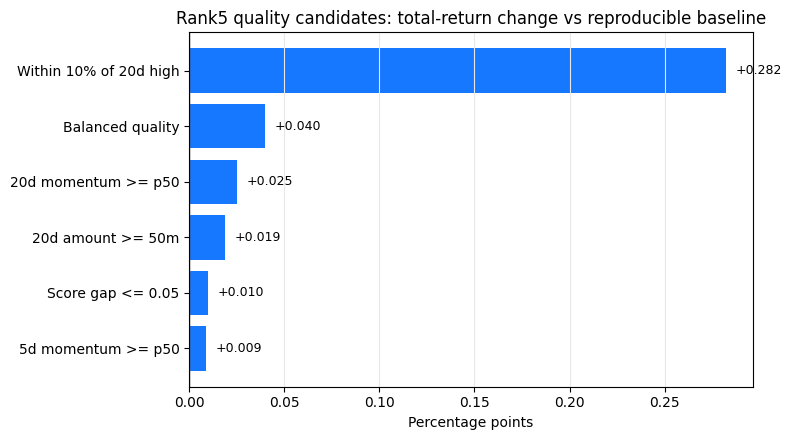

In [4]:
plot_rows = candidate_table[candidate_table['candidate'] != 'Reproducible baseline'].sort_values('return_delta_pp')
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(plot_rows['candidate'], plot_rows['return_delta_pp'], color='#1677ff')
ax.axvline(0, color='#31343a', linewidth=1)
ax.set_title('Rank5 quality candidates: total-return change vs reproducible baseline')
ax.set_xlabel('Percentage points')
ax.grid(axis='x', color='#e5e7eb', linewidth=0.8)
for index, value in enumerate(plot_rows['return_delta_pp']):
    ax.text(value + 0.005, index, f'{value:+.3f}', va='center', fontsize=9)
fig.tight_layout()
plt.show()

In [5]:
diagnostics = experiment['baseline_rank5_diagnostics']
feature_table = pd.DataFrame.from_dict(diagnostics['feature_outcome_diagnostic'], orient='index')
assert (feature_table['non_null_count'] == diagnostics['closed_rank5_count']).all()
feature_table[['non_null_count', 'winner_median', 'loser_median', 'overall_median']].round(4)

,non_null_count,winner_median,loser_median,overall_median
avg_amount_20d,22,1.479219e+08,9.339660e+07,1.157631e+08
distance_from_20d_high,22,-3.550000e-02,-1.360000e-02,-3.160000e-02
return_20d_percentile,22,8.131000e-01,9.365000e-01,9.119000e-01
return_5d_percentile,22,7.978000e-01,8.803000e-01,8.359000e-01
score,22,3.168300e+00,3.299100e+00,3.224400e+00


## Takeaways

1. Retain R14; no candidate qualifies for a one-for-one replacement.
2. Do not tune more simple Rank5 thresholds on these 22 closed trades. Improvements are below 0.3 percentage points and come with worse execution coverage.
3. The Rank5 winner/loser medians are not monotonically separated across score and momentum features, so a stronger cutoff is not supported.
4. A future round should require genuinely new PIT information or additional forward observations, not another threshold grid over the same fields.